In [2]:
from itscalledsoccer.client import AmericanSoccerAnalysis
from plotnine import *
from colour import Color
import numpy as np
import pandas as pd

asa_client = AmericanSoccerAnalysis()

In [ ]:
def decorate_team_ids(df):
    team_ids = set()

    for c in df.columns:
        if "team_id" in c:
            team_ids |= set(df[c].unique())

    teams_df = asa_client.get_teams(ids=list(team_ids))
    team_map = dict(zip(teams_df.team_id, teams_df.team_abbreviation))

    for c in df.columns:
        if "team_id" in c:
            df[c.replace("team_id", "team")] = df[c].map(team_map)
            df[c.replace("team_id", "team_logo")] = (
                "https://american-soccer-analysis-headshots.s3.amazonaws.com/club_logos/"
                + df[c]
                + ".png"
            )

    return df


def decorate_player_ids(df):
    player_ids = set()

    for c in df.columns:
        if "player_id" in c:
            player_ids |= set(df[c].unique())

    players_df = asa_client.get_players(ids=list(player_ids))
    player_map = dict(zip(players_df.player_id, players_df.player_name))

    for c in df.columns:
        if "player_id" in c:
            df[c.replace("player_id", "player")] = df[c].map(player_map)
            df[c.replace("player_id", "player_headshot")] = (
                "https://american-soccer-analysis-headshots.s3.amazonaws.com/player_headshots/"
                + df[c]
                + ".png"
            )

    return df

In [ ]:
games_df = asa_client.get_games(seasons="2024", leagues="nwsl")

In [9]:
list(games_df.game_id)

['Oa5w6k8AM1',
 '315VzLr659',
 'EGMP8oPjMa',
 '9z5kzwJlMA',
 'wvq9wl4ZMW',
 'vzqozgWj5a',
 'gOMnzWBmMw',
 'wvq9w4lNMW',
 '2lqReN9a5r',
 'vzqozWgN5a',
 'gOMnzBW8Mw',
 'gpMOlVnD5z',
 '0Oq6e0Dg56',
 '7VqGPGwzQv',
 '0x5gzZawM7',
 'KAqBowpmQb',
 'NWMWzrNDQl',
 'eVq3lENXQW',
 'Oa5w69kDM1',
 'jYQJynWZqG',
 '2lqReN9J5r',
 'vzqozWgJ5a',
 'gpMOlVnr5z',
 'gOMnzBWlMw',
 '0Oq6e0Dx56',
 '7VqGPGwjQv',
 '0x5gzZaPM7',
 'NWMWzrNEQl',
 'KAqBowWBQb',
 'eVq3lE8VQW',
 'jYQJyn9kqG',
 'Oa5w69r4M1',
 'Xj5YzrXRqb',
 'e7MzoPdG5r',
 'N6Mmz39x5E',
 'p6qbzdwwq0',
 'ljqEkW64Mx',
 'XVqK7ok0q0',
 'BLMvGRYW5x',
 'zeQZzl2rQK',
 '4wM480dNMj',
 '4JMAnJB15K',
 'kRQazYJjMK',
 'xW5pJgPJQg',
 'KPqjzbnYq6',
 'aDQ0D013QE',
 'NPqxOklX59',
 '9vQ2r0lmQK',
 'odMXzjexqY',
 'KXMezAWP56',
 '9YqdzEBEMv',
 'Vj58J0xLQ8',
 'OlMlzYRDqL',
 'a35r36N2qL',
 'eV5D9BGnqK',
 '2vQ110rOQr',
 '7vQ7X02GMD',
 'raMynV8d5d',
 'gjMNrkLDMK',
 'Pk5LDRVY5O',
 'EGMP8Py6Ma',
 '315Vzr8n59',
 '9z5kzJodMA',
 'wvq9w40BMW',
 '2lqReNDJ5r',
 'vzqozWVJ5a',
 'gOMnzBkl

In [17]:
games_df = asa_client.get_games(seasons=["2023", "2024", "2025"], leagues="nwsl")

shots_df = decorate_player_ids(
    decorate_team_ids(
        asa_client._get_stats(
            game_id=list(games_df.game_id), type="shots", entity="games", leagues="nwsl"
        )
    )
)

In [18]:
shots_df.T

,0,1,2,3,4,5,6,7,8,9,...,10696,10697,10698,10699,10700,10701,10702,10703,10704,10705
game_id,zeQZzlrKQK,BLMvGRYW5x,gjMNpdn0qK,gOMnzWBmMw,0Oq6bZ8dq6,xW5pJg9lQg,Pk5LpdmO5O,Pk5L0DL75O,e7MzoPrX5r,NWMW0zaN5l,...,wvq9wl4ZMW,eVq3l40XQW,EGMP8oPjMa,eVq3l40XQW,eVq3l40XQW,wvq9wl4ZMW,wvq9wl4ZMW,wvq9wl4ZMW,wvq9wl4ZMW,eVq3l40XQW
period_id,1,1,1,1,1,1,1,1,1,1,...,3,3,4,4,4,4,4,4,4,4
expanded_minute,3,1,1,1,1,1,1,1,1,1,...,117,119,138,122,127,124,130,133,134,138
game_minute,2,0,0,0,0,0,0,0,0,0,...,104,106,120,106,111,108,114,117,118,122
team_id,7vQ7BBzqD1,XVqKeVKM01,KPqjw8PQ6v,XVqKeVKM01,zeQZeazqKw,XVqKeVKM01,zeQZeazqKw,7vQ7BBzqD1,eV5DR6YQKn,Pk5LeeNqOW,...,aDQ0lzvQEv,raMyrr25d2,aDQ0lzvQEv,raMyrr25d2,Pk5LeeNqOW,315VnJ759x,315VnJ759x,315VnJ759x,aDQ0lzvQEv,Pk5LeeNqOW
shooter_player_id,NPqxxjmkq9,315VX0vYQ9,2lqRjRg2qr,BLMv7oZO5x,vzqodvZjQa,NWMWlgLE5l,vzqodvZjQa,jYQJg0EdMG,315V7xlnq9,4JMAaW7OMK,...,N6MmoKJwqE,OlMl9V9D5L,7VqGjK3A5v,wvq9gN17MW,4JMAaW7OMK,NPqxev0jQ9,XVqKeJGwM0,9z5kWjNj5A,N6MmoKJwqE,KAqBNn1Zqb
assist_player_id,0,0,0,ljqE241EQx,2vQ143Ylqr,gOMnRnYmMw,NWMWly9D5l,2lqR7prDQr,gOMnRboOMw,315VXRDbQ9,...,0Oq6243Pq6,wvq9gN17MW,2vQ14jmLqr,eVq3j0y65W,0,XVqKeJGwM0,9z5kWjNj5A,9YqdoxJm5v,0,0
shot_location_x,88.5,81.1,84.7,89.1,88.5,91.5,92.4,93.0,94.9,69.4,...,87.1,80.7,90.5,81.5,79.2,94.5,92.8,65.6,80.3,87.7
shot_location_y,50.0,64.0,46.4,63.1,64.1,71.6,45.8,71.1,45.8,30.3,...,25.6,25.6,60.0,37.3,40.3,43.4,35.9,38.3,34.7,26.1
shot_end_location_x,100.0,100.0,100.0,100.0,100.0,92.5,96.3,98.6,100.0,100.0,...,95.9,100.0,99.3,100.0,100.0,100.0,94.9,86.2,100.0,96.0


In [19]:
from sklearn import metrics

In [20]:
metrics.roc_auc_score(
    y_true=shots_df.goal,
    y_score=shots_df.shot_xg,
)

0.7902109843034357

In [21]:
metrics.roc_auc_score(
    y_true=shots_df.goal,
    y_score=shots_df.shot_psxg,
)

0.9646103818494169

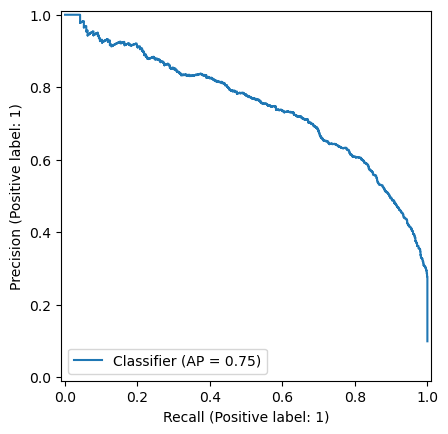

In [ ]:
metrics.PrecisionRecallDisplay.from_predictions(
    y_true=shots_df.goal, y_pred=shots_df.shot_psxg
)

In [25]:
shots_df.shot_xg.sum()

1141.3879

In [26]:
shots_df.goal.sum()

1058

In [27]:
shots_df.shot_psxg.sum()

1048.9785000000002